# 💰 Discount Analysis

## Business Objective

Discounts are commonly used to increase sales and attract customers.

However, excessive discounts may reduce profitability.

### Business Questions

1. 💸 Do higher discounts increase sales?
2. 📉 Do higher discounts reduce profit?
3. 🎯 Which discount range performs best?
4. ⚠️ Which categories receive the highest discounts?
5. 💡 What discount strategy should the business follow?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv('../data/Superstore.csv', encoding="latin1")

In [2]:
discount_summary = (

    df.groupby("Discount")

    .agg(

        Total_Sales=("Sales","sum"),

        Total_Profit=("Profit","sum"),

        Orders=("Order ID","nunique"),

        Avg_Sales=("Sales","mean")

    )

    .sort_index()

)

discount_summary

,Total_Sales,Total_Profit,Orders,Avg_Sales
Discount,,,,
0.00,1.087908e+06,320987.6032,2644,226.742074
0.10,5.436935e+04,9029.1770,89,578.397351
0.15,2.755852e+04,1418.9915,51,529.971567
0.20,7.645944e+05,90337.3060,2407,209.076940
0.30,1.032267e+05,-10369.2774,211,454.742974
0.32,1.449346e+04,-2391.1377,27,536.794770
0.40,1.164178e+05,-23057.0504,185,565.134874
0.45,5.484974e+03,-2493.1111,10,498.634000
0.50,5.891854e+04,-20506.4281,64,892.705152


In [3]:
discount_summary.style.format({

"Total_Sales":"${:,.2f}",

"Total_Profit":"${:,.2f}",

"Avg_Sales":"${:,.2f}"

}).background_gradient(cmap="RdYlGn")

,Total_Sales,Total_Profit,Orders,Avg_Sales
Discount,,,,
0.000000,"$1,087,908.47","$320,987.60",2644,$226.74
0.100000,"$54,369.35","$9,029.18",89,$578.40
0.150000,"$27,558.52","$1,418.99",51,$529.97
0.200000,"$764,594.37","$90,337.31",2407,$209.08
0.300000,"$103,226.65","$-10,369.28",211,$454.74
0.320000,"$14,493.46","$-2,391.14",27,$536.79
0.400000,"$116,417.78","$-23,057.05",185,$565.13
0.450000,"$5,484.97","$-2,493.11",10,$498.63
0.500000,"$58,918.54","$-20,506.43",64,$892.71


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


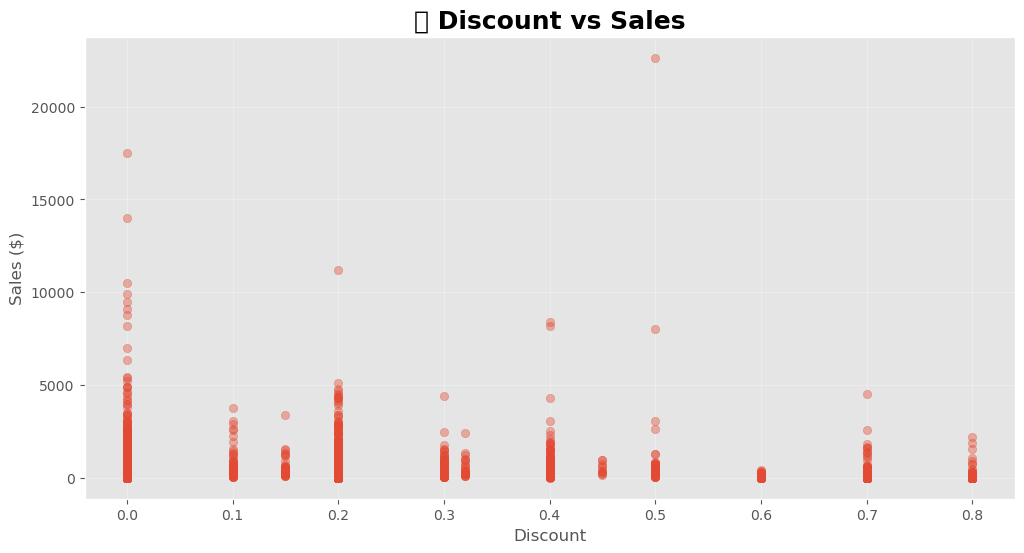

In [4]:
plt.figure(figsize=(12,6))

plt.scatter(

df["Discount"],

df["Sales"],

alpha=0.4

)

plt.title(

"💸 Discount vs Sales",

fontsize=18,

fontweight="bold"

)

plt.xlabel("Discount")

plt.ylabel("Sales ($)")

plt.grid(alpha=.3)

plt.show()

## 🧠 Business Insight

The relationship between discounts and sales is not perfectly linear.

While some highly discounted orders achieve high sales, many discounted transactions remain relatively small.

This suggests that discounts alone may not be the primary driver of revenue.

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


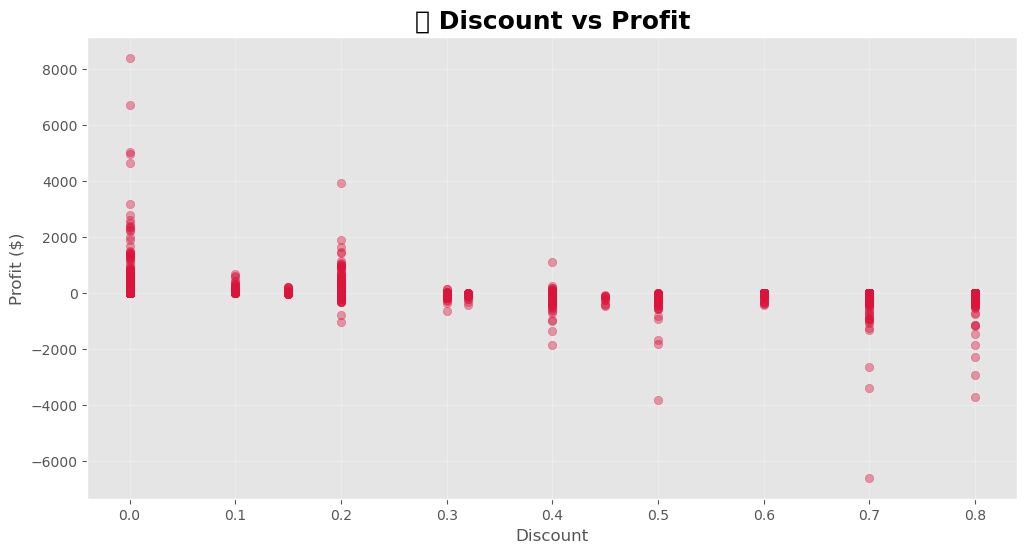

In [5]:
plt.figure(figsize=(12,6))

plt.scatter(

df["Discount"],

df["Profit"],

alpha=.4,

color="crimson"

)

plt.title(

"📉 Discount vs Profit",

fontsize=18,

fontweight="bold"

)

plt.xlabel("Discount")

plt.ylabel("Profit ($)")

plt.grid(alpha=.3)

plt.show()

## 🧠 Business Insight

Higher discounts appear to be associated with lower profitability.

A significant number of heavily discounted transactions generate little or even negative profit.

This indicates that aggressive discounting may erode profit margins.

In [6]:
discount_profit = (

df.groupby("Discount")

["Profit"]

.mean()

)

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

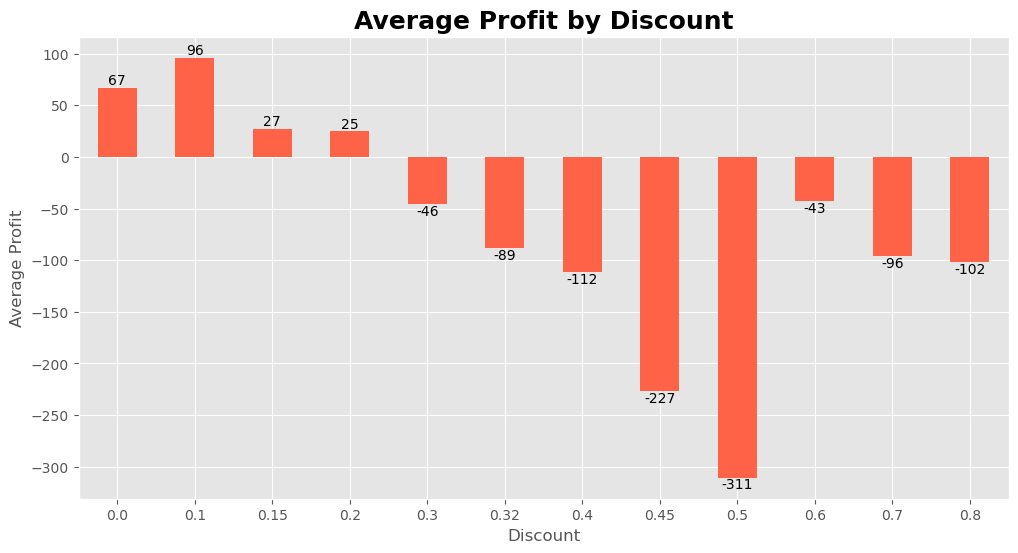

In [7]:
ax=(

discount_profit

.plot(

kind="bar",

figsize=(12,6),

color="tomato"

)

)

plt.title(

"Average Profit by Discount",

fontsize=18,

fontweight="bold"

)

plt.ylabel("Average Profit")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

In [8]:
category_discount=(

df.groupby("Category")

["Discount"]

.mean()

.sort_values(

ascending=False

)

)

category_discount

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


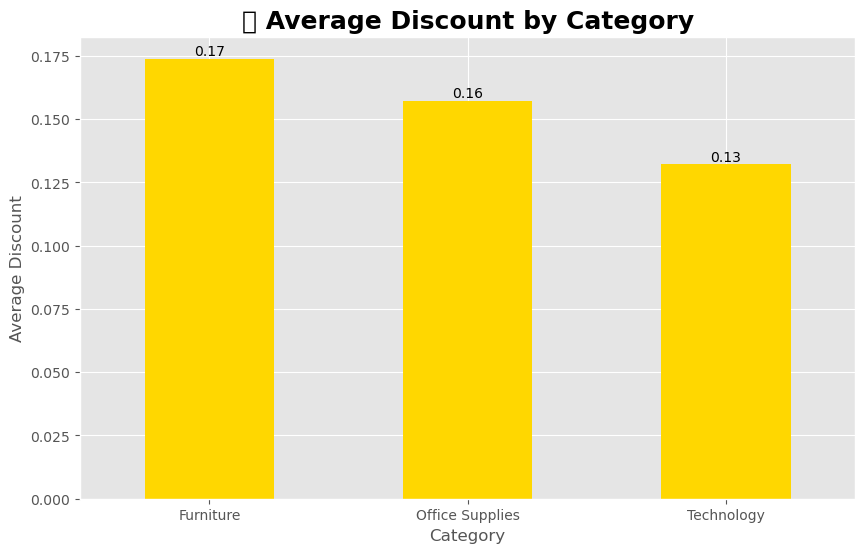

In [9]:
ax=(

category_discount

.plot(

kind="bar",

figsize=(10,6),

color="gold"

)

)

plt.title(

"🏷️ Average Discount by Category",

fontsize=18,

fontweight="bold"

)

plt.ylabel("Average Discount")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")

plt.show()

## 🧠 Business Insight

Categories receiving consistently higher discounts should be evaluated carefully.

If higher discounts do not translate into stronger profits, pricing strategies may require optimization.

In [10]:
df["Discount Category"]=(

pd.cut(

df["Discount"],

bins=[-0.01,.0,.2,.5,1],

labels=[

"No Discount",

"Low",

"Medium",

"High"

]

)

)

In [11]:
bucket_summary=(

df.groupby(

"Discount Category"

)

.agg(

Revenue=("Sales","sum"),

Profit=("Profit","sum"),

Orders=("Order ID","nunique")

)

)

bucket_summary

C:\Users\gyanr\AppData\Local\Temp\ipykernel_22160\4055486292.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,Revenue,Profit,Orders
Discount Category,,,
No Discount,1.087908e+06,320987.6032,2644
Low,8.465222e+05,100785.4745,2507
Medium,2.985414e+05,-58817.0047,468
High,6.422874e+04,-76559.0513,685


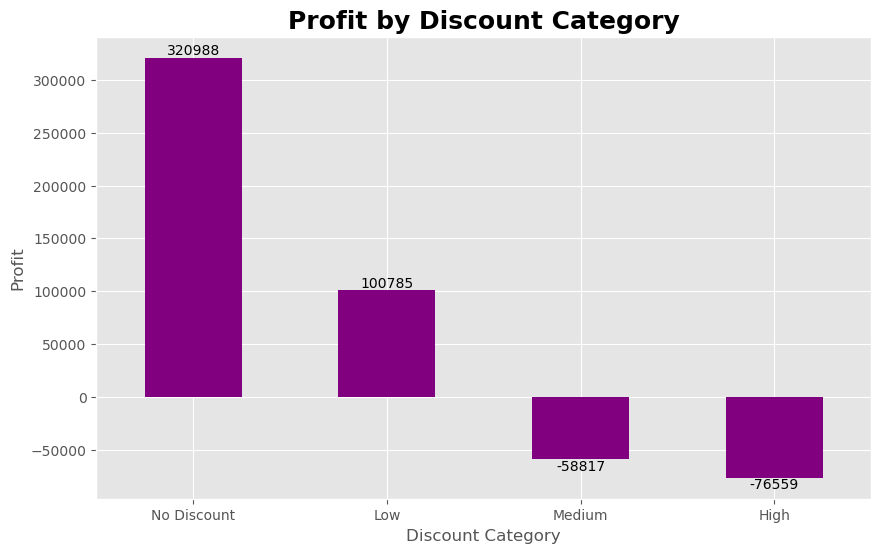

In [12]:
ax=(

bucket_summary

["Profit"]

.plot(

kind="bar",

figsize=(10,6),

color="purple"

)

)

plt.title(

"Profit by Discount Category",

fontsize=18,

fontweight="bold"

)

plt.ylabel("Profit")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 💡 Business Recommendation

The company should avoid excessive discounting unless supported by a measurable increase in sales.

Instead of applying uniform discounts across products, management should adopt targeted discount strategies based on profitability and customer demand.